In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
from langchain.chat_models import init_chat_model

In [6]:
model=init_chat_model("groq:qwen/qwen3-32b")

In [7]:
#node funcaionality
def chatbot(state:State):
    return {"messages":[model.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)
#add node
graph_builder.add_node("llmchatbot",chatbot)
#add edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#build graph
graph=graph_builder.compile()

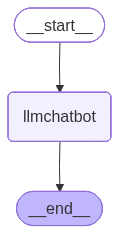

In [9]:
#visualization the graph
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response=graph.invoke({"messages":"Hi"})

In [11]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". I need to respond appropriately. Since it\'s just a greeting, I should reply with a friendly and welcoming message. Maybe ask how I can assist them. Keep it open-ended so they feel comfortable to ask for help. I should also make sure the tone is positive and helpful. Let me check if there\'s any specific way they want the response. No, it\'s just a general hi. Alright, something like "Hello! How can I assist you today?" should work. Maybe add an emoji to keep it friendly. Yeah, that\'s good. Let me make sure there are no typos. All set.\n</think>\n\nHello! How can I assist you today? 😊'

In [12]:
for event in graph.stream({"messages":"Hello how are you"}):
    for values in event.values():
        print(values["messages"][-1].content)

<think>
Okay, the user said, Hello how are you. I need to respond appropriately. First, I should acknowledge their greeting and offer a friendly reply. Let me make sure to keep the tone warm and welcoming. I'll check for any nuances or context that might require a different response, but since there's none, a simple and cheerful reply should work best. I should ask how they're doing too to keep the conversation flowing naturally. Let me put that together in a clear and concise way.
</think>

Hello! I'm doing well, thank you! How are you feeling today? 😊


In [17]:
##chatbot with tools
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represents

In [31]:
##custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    Args:
        a(int): first int
        b(int): second int
    Returns:
        int: output int
    """
    return a*b


In [32]:
tools=[tool,multiply]

In [33]:
llm_with_tools=model.bind_tools(tools)

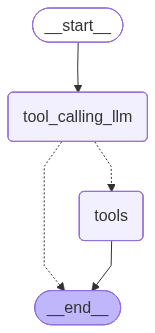

In [22]:
##stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

##compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"what is the recent ai message"})

In [26]:
response['messages'][-1].content

'{"query": "recent AI message", "follow_up_questions": null, "answer": null, "images": ["https://images.theconversation.com/files/726934/original/file-20260329-63-igpdj4.png?ixlib=rb-4.1.0&q=45&auto=format&w=1000&fit=clip", "https://about.fb.com/wp-content/uploads/2023/12/03_Reels.png?resize=960%2C836", "https://www.cnet.com/a/img/resize/5fbdba912b9ef57b7d104e1c2473cf1a2349009e/hub/2024/02/23/eeacc071-6c34-42da-aa9b-4e54aad089b4/gemini-msg.jpg?auto=webp&fit=crop&height=675&width=1200", "https://textdrip.com/wp-content/uploads/2025/01/Healthcare.webp", "https://imgproxy.divecdn.com/9PERfQS2Goay-UieLULEppTxeh85y-ZaLJspa6vPrTo/g:ce/rs:fill:320:466:0/Z3M6Ly9kaXZlc2l0ZS1zdG9yYWdlL2RpdmVpbWFnZS9pZ19haTEucG5n.webp"], "results": [{"url": "https://futurism.com/artificial-intelligence/catastrophic-leak-all-messages-search-history", "title": "Get Ready for a Catastrophic Leak That Reveals All Your Messages and Search History", "content": "In short, recent AI coding advancements have effectively d

In [28]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai message
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vrbfb0ms7)
 Call ID: vrbfb0ms7
  Args:
    include_images: True
    query: recent AI message
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI message", "follow_up_questions": null, "answer": null, "images": ["https://images.theconversation.com/files/726934/original/file-20260329-63-igpdj4.png?ixlib=rb-4.1.0&q=45&auto=format&w=1000&fit=clip", "https://about.fb.com/wp-content/uploads/2023/12/03_Reels.png?resize=960%2C836", "https://www.cnet.com/a/img/resize/5fbdba912b9ef57b7d104e1c2473cf1a2349009e/hub/2024/02/23/eeacc071-6c34-42da-aa9b-4e54aad089b4/gemini-msg.jpg?auto=webp&fit=crop&height=675&width=1200", "https://textdrip.com/wp-content/uploads/2025

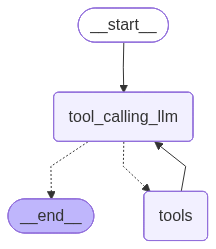

In [34]:
##react agent
##stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")

##compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
response=graph.invoke({"messages":"what is the recent news in nlp and what is 5*23"})

In [37]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent news in nlp and what is 5*23
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8d0jb1hzh)
 Call ID: 8d0jb1hzh
  Args:
    query: recent advancements in natural language processing
    search_depth: advanced
    time_range: week
    topic: news
  multiply (1k7ybdhwa)
 Call ID: 1k7ybdhwa
  Args:
    a: 5
    b: 23
================================= Tool Message =================================
Name: tavily_search

{"query": "recent advancements in natural language processing", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nature.com/articles/s41551-026-01719-2", "title": "BRIDGE: benchmarking large language models for understanding real-world clinical practice texts - Nature", "score": 0.72907686, "published_date": "Wed, 17 Jun 2026 00:00:00 GMT", "content": "Article \n   CAS \n   Pub

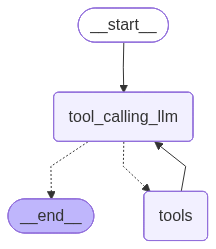

In [38]:
##adding memory in our agent

##stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

#node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")

##compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"1"}}
graph.invoke({"messages":"hi my name is mayank"},config=config)

UsageError: Invalid config statement: '{"configurable":{"thread_id":"1"}}', should be `Class.trait = value`.
